In [2]:
# Simple Chest X-Ray Classification with DenseNet121
import os, zipfile, torch, torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import numpy as np
from collections import Counter

In [3]:
# 1. Download Data (ekbar run korlei hobe)

DATA_ROOT = "./chest_xray"

if not os.path.exists(DATA_ROOT):
    print("Downloading dataset...")
    os.system("kaggle datasets download -d paultimothymooney/chest-xray-pneumonia")
    with zipfile.ZipFile("chest-xray-pneumonia.zip", "r") as z:
        z.extractall(".")
    os.remove("chest-xray-pneumonia.zip")
    print("Download complete")
else:
    print("Dataset already exists")


Download complete


In [4]:
# 2. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [5]:
# 3. Simple transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# Load full training data
full_train = datasets.ImageFolder(f"{DATA_ROOT}/train", transform=train_transform)
test_data = datasets.ImageFolder(f"{DATA_ROOT}/test", transform=test_transform)

# Split train into train (80%) and validation (20%)
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_data, val_data = random_split(full_train, [train_size, val_size])

# Create data loaders
BATCH = 32
train_loader = DataLoader(train_data, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH, shuffle=False)

class_names = full_train.classes
print(f"Classes: {class_names}")
print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Classes: ['NORMAL', 'PNEUMONIA']
Train: 4172, Val: 1044, Test: 624


In [7]:
# 4. Build Model
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Freeze all layers (we'll only train the last layer)
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier for our 2 classes
model.classifier = nn.Linear(1024, 2)
model = model.to(device)

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable parameters: 2,050


In [8]:
# 5. Loss & Optimizer

# Handle class imbalance
targets = [full_train.targets[i] for i in train_data.indices]
class_counts = Counter(targets)
weights = torch.tensor([len(targets)/class_counts[0], len(targets)/class_counts[1]]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
# 6. Training Functions
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(x)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    correct = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return correct / len(loader.dataset), all_preds, all_labels

In [10]:
# 7. Train Model
EPOCHS = 10
best_val_acc = 0
history = {'train_acc': [], 'val_acc': []}

print("\nTraining started...\n")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer)
    val_acc, _, _ = evaluate(model, val_loader)
    
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

print(f"\n Best Validation Accuracy: {best_val_acc:.3f}")

# Load best model
model.load_state_dict(torch.load('best_model.pth'))


Training started...

Epoch  1/10 | Train Acc: 0.886 | Val Acc: 0.889
Epoch  2/10 | Train Acc: 0.921 | Val Acc: 0.933
Epoch  3/10 | Train Acc: 0.933 | Val Acc: 0.947
Epoch  4/10 | Train Acc: 0.941 | Val Acc: 0.955
Epoch  5/10 | Train Acc: 0.939 | Val Acc: 0.958
Epoch  6/10 | Train Acc: 0.948 | Val Acc: 0.945
Epoch  7/10 | Train Acc: 0.946 | Val Acc: 0.956
Epoch  8/10 | Train Acc: 0.948 | Val Acc: 0.960
Epoch  9/10 | Train Acc: 0.954 | Val Acc: 0.966
Epoch 10/10 | Train Acc: 0.951 | Val Acc: 0.959

✅ Best Validation Accuracy: 0.966


<All keys matched successfully>


Test Accuracy: 0.859 (85.9%)


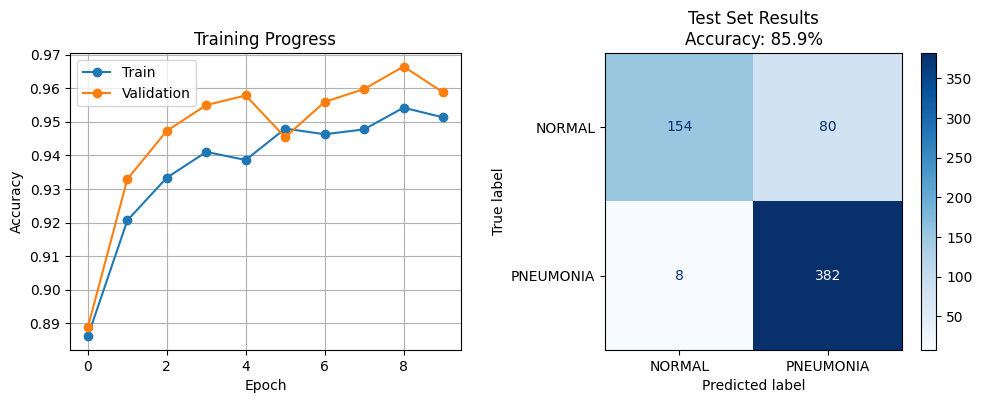

In [11]:
# 8. Plot Results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train', marker='o')
plt.plot(history['val_acc'], label='Validation', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Progress')
plt.legend()
plt.grid(True)

# Test evaluation
test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f"\nTest Accuracy: {test_acc:.3f} ({test_acc*100:.1f}%)")

plt.subplot(1, 2, 2)
ConfusionMatrixDisplay.from_predictions(
    test_labels, test_preds, 
    display_labels=class_names,
    cmap='Blues', 
    ax=plt.gca()
)
plt.title(f'Test Set Results\nAccuracy: {test_acc:.1%}')

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()



In [12]:
# 9. Final Report
print("\n" + "="*40)
print("FINAL TEST RESULTS")
print("="*40)
print(classification_report(test_labels, test_preds, target_names=class_names))

# Save final model
torch.save(model.state_dict(), 'chestxray_densenet.pth')
print("\nModel saved as 'chestxray_densenet.pth'")


FINAL TEST RESULTS
              precision    recall  f1-score   support

      NORMAL       0.95      0.66      0.78       234
   PNEUMONIA       0.83      0.98      0.90       390

    accuracy                           0.86       624
   macro avg       0.89      0.82      0.84       624
weighted avg       0.87      0.86      0.85       624


Model saved as 'chestxray_densenet.pth'
